# Estudio de métodos aproximados para el aprendizaje por refuerzo en entornos continuos

## Introducción

Dentro del paradigma del aprendizaje por refuerzo, los algoritmos realizados hasta la fecha suelen funcionar muy bien en problemas simples, es decir, aquelos con un número reltivamente pequeño y manejable de estados y acciones. Es importante anotar que, en el mundo real esta situación realmente no se da y es que en muchas situaciones un robot puede navegar en un espacio continuo, por ejemplo, un robot que juega a un videojuego viendo píxeles, o un sistema que controla una central eléctrica. En las situaciones descritas todos los espacios de estos son o bien enormes o incluso infinitos. Ante esta problemática, nacen los denominados **métodos aproximados**.

La implementación de métodos aproximados se puede realizar de varias maneras, la primera, consiste en la discretización de aquellos espacios continuos para poder trabajar en un espacio de estados gestionable por el algoritmo que trabaje con un sistema de acciones y recompensas discreto, sin embargo, esto tiene una limitación, y es que a consecuencia de realizar la discretización de los espacios continuos se induce a una imprecisión a la hora de operar con el problema que se quiera afrontar. En aquellos espacios continuos infinitos se da otro problema y es que hay que establecer cotas superior e inferior de trabajo para poder realizar la discretización. El segundo método de trabajo consiste en trabajar con algoritmos que directamente tengan soporte para espacios continuos, como es el caso de una red neuronal, entrando en el paradigma de trabajo de *Deep Reinforcement Learning*.

En este notebook vamos a trabajar ambas soluciones para el mismo problema. Concretamente, en función de la solución optada el flujo de trabajo será el siguiente:

1. El agente observa el estado en el que se encuentra (ya sea continuo o discreto por aproximación).
2. En función de su política, toma una acción (en este caso discreto).
3. La acción actualiza el entorno y genera un nuevo estado y una recompensa instantánea.
4. La nueva información se le pasa al algoritmo de aprendizaje para actualizar los valores de los pesos. Esta actualización varía en función del algoritmo utilizado.

Esto se repite hasta que el agente alcanza un estado terminal, lo que marca el fin del episodio. El proceso se repite durante un cierto número de episodios hasta que, idealmente, la política del agente converge a una solución.

El objetivo de este notebook es comparar diversos algoritmos de aprendizaje; en concreto, se han implementado los siguientes métodos aproximados: SARSA Semi-Gradient, Deep Q-Learning y Double Deep Q-Learning. Para facilitar el proceso de aprendizaje y con el objeto de que el código fuese lo más modular posible, se han implementado cuatro módulos dentro del directorio ``./src/``:

- ``Plotting``: contiene todas las funciones que usaremos para representar gráficamente el aprendizaje y los resultados de cada algoritmo.
- ``Policies``: incluye varias políticas que los agentes pueden usar. Se ha impleemntado la politica de epsilon a emplear en este estudio, $\epsilon$-greedy. Esta política hereda de una clase abstracta que incluye un método para seleccionar una acción dado un estado y una tabla Q (o tabla de pesos), así como métodos para calcular la probabilidad de seleccionar cada una de las acciones en un cierto estado y el valor de recompensa esperada en un estado.
- ``Learners``: en él se definen todos los algoritmos de aprendizaje que hemos mencionado antes, los cuales heredan de una clase abstracta que incluye un método para inicializar el episodio, un método que se ejecuta en cada paso del aprendizaje y uno que realiza una actualización al final del episodio en caso de que sea necesario. También incorpora una función para resetear el algoritmo en cada ejecución. Dentro de esta sección se incluye la red neuronal empleada para los métodos Deep Q.
- ``Agents``: este módulo contiene una clase Agent que representa al agente, que es quien interactúa con el entorno tomando acciones en base a una política, recibe recompensas y recopila estadísiticas durante el aprendizaje. Este agente es totalmente agnóstico al algoritmo de aprendizaje y a la política: el bucle de aprendizaje es siempre el mismo.
- ``Utils``: este módulo incluye utilidades diversas, podemos encontrar *episode_utils*, en el que hay funciones definidas para generar y exportar en formato GIF la visualización de la ejecución del algoritmo a elegir con el problema empleado. En *tile_coding* encontramos el sistema de discretización del espacio de acciones continuo, además de una función para adaptar este en SARSA Semi-Gradient.

## Preparación del entorno

In [1]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en Colab o en local, dentro del repositorio clonado, se deberá ejecutar una de las dos siguientes secciones. 

### Ejecución en Colab

In [2]:
# Clonar el repositorio

In [3]:
# Añadir los directorio fuentes al path de Python

### Ejecución en local

In [4]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\entornos_complejos\\src']


### Importación de librerías y módulos

In [5]:
import gymnasium as gym
import numpy as np

from agents import Agent
from utils import TileCodingEnv, make_tile_feature_fn, run_episode_greedy, frames_to_gif
from policies import EpsilonGreedyPolicy
from learners import SARSASemiGradient, DQNLearner, QNetwork, DoubleDQNLearner
from plotting import plotting
import matplotlib.pyplot as plt
import random
import torch

Con la siguiente función conseguimos garantizar la repoducibildad de los experimentos

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Semilla global fijada en: {seed}")

## Entorno de Gymnasium

En cuanto al entorno de la librería Gymnasium, hemos decidido emplear el entorno denominado ***"CartPole"*** dado que éste problema funciona muy bien con la implementación que deseamos realizar. El entorno es un mundo grid con 4 variables observables descritas de la siguiente manera:

- Cart Position: $[-4.8, 4.8]$
    - Posición en el eje X del carro.
- Cart Velocity: $[-\infty, +\infty]$
    - Velocidad del carro.
- Pole Angle: $[-0.418, 0.418]$
    - Ángulo de la pértiga
- Pole Angular Velocity: $[-\infty, +\infty]$
    - Velocidad angular de la pértiga.

El espacio de acciones queda definido bajo dos valores:

- 0: empujar el carro a la izquierda.
- 1: empujar el carro a la derecha.

Cuando se inicializa ***"CartPole"***, se le asigna a todas las 4 variables observables un valor aleatorio uniforme comprendido en el rango $[-0.05, 0.05]$.

La condición de fin de episodio se da cuando ocurre al menos una de estas situaciones:

1. El ángulo de la pértiga es mayor que $\pm12º$
2. La posición del carro es mayor que $\pm2.4$ (el centro del carro llega al límite de la imagen)
3. El episodio es mayor que el número establecido.



Dado que el objetivo es mantener el carro lo más recto cuanto más tiempo sea posible, por defecto, una recompensa de $+1$ se otorga a cado paso llevado a cabo, inlcuyendo el paso de terminación.

In [7]:
env = gym.make("CartPole-v1")
env = gym.wrappers.TimeLimit(env, max_episode_steps=1000)
state_size = 4 # CartPole: 4 variables de estado.
action_size = env.action_space.n  # CartPole: 2 acciones posibles.
env.reset()

(array([-0.0279473 , -0.04885622,  0.03595446, -0.00293806], dtype=float32),
 {})

Con el objetivo de dar consistencia respecto al resto de entorno empleados, el número de episodios máximo para ***"CartPole"*** es de 1000.

## Entrenamientos

Para la mayoría de los entrenamientos que vamos a realizar, usaremos los siguientes parámetros (a no ser que se especifique lo contrario):

- Tasa de descuento $\gamma$ de $0.95$.
- Política $\epsilon$-greedy, con el valor de $\epsilon$ de $0.1$.
- El número de episodios en cada ejecución será de 400, y los resultados serán la media de 10 ejecuciones.

A continuación definimos estos parámetros comunes:

### Parámetros comunes

In [8]:
gamma = 0.95 # Tasa de descuento (importancia que el agente proporciona a futuras recompensas)
n_steps = 5 # Para diferencias temporales de n pasos
num_episodes = 400 # Nº de episodios por ejecución
n_runs = 10 # Nº de ejecuciones (los resultados serán la media de ellas)
SEED = 123 # Reproducibilidad

policy = EpsilonGreedyPolicy(epsilon=0.1)

In [9]:
set_seed(SEED)

Semilla global fijada en: 123


### Parámetros específicos

A consecuencia de la disparidad de parámetros existente entre la implementación de SARSA Semi-Gradient y los algoritmos Deep Q, vamos a especificar para cada caso sus parámetros:

#### SARSA Semi-Gradient

Para SARSA Semi-Gradient, como este algoritmo trabajo con espacios discretos, tenemos que transformar los espacios continuos a espacios discretos.

Tenemos 4 espacios observables. Primero es necesario definir las cotas superior e inferior de cada espacio observable, para los valores continuos de espacio infinito esto es sumamente importante, mientras que para el resto de espacios observables que ya tengan cotas establecidas no resulta un problema (utilizaremos todo su espacio). Para los espacios observables infinitos definiremos como cota inferior y superior:

- Cart Velocity: $[-3, 3]$
- Pole Angular Velocity: $[-3, 3]$

Una vez que tenemos las cotas inferior y superior para cada espacio observable, ahora toca definir la cantidad de bins o cantidad de discretizaciones que va a poseer cada espacio observable, concretamente, vamos a dividir cada segmento en 8 unidades.

Esto no es suficiente, y es que necesitamos definir la cantidad de tilings que va a tener cada espacio observable. Vamos a establecer 4 tilings por cada espacio observable. Esto implica que vamos a tener 4 representaciones distintas para un mismo espacio bajo un offset aleatorio predeterminado del $\pm20\%$ por cada espacio observable en el que cada tiling esta dividido en 8 bins de misma longitud. Teniendo la posibilidad de que para un mismo valor continuo a la hora de discretizar su valor se encuentre en índices distintos para cada tiling.

Una manera de ilustrar esto es con el siguiente ejemplo simple:

Supuesto: Tenemos una variable observable en el rango $[-1,1]$, vamos a definir para este simple ejemplo 4 bins y 3 tilings, y vamos a generarlos de forma aleatoria (offset aleatorio dentro del margen de $\pm20\%$ para cada cota):

- Tiling 0: $[-1.1, 1.05]$ -> Cada bin tiene tamaño $0.5375$.
- Tiling 1: $[-1.2, 1]$ -> Cada bin tiene tamaño $0.55$.
- Tiling 2: $[-1.15, 1.1]$ -> Cada bin tiene tamaño $0.5625$.

Cuando queremos discretizar el valor $0.5$ para este espacio observable lo que hacemos es devolver el índice del bin al que pertenece en cada tiling, es decir:

- Tiling 0: Bin de índice 2, es decir, se encuentra en el bin comprendido en el intervalo $[-0.025, 0.5125]$
- Tiling 1: Bin de índice 3, es decir, se encuentra en el bin comprendido en el intervalo $[0.45, 1]$
- Tiling 2: Bin de índice 2, es decir, se encuentra en el bin comprendido en el intervalo $[-0.025, 0.5375]$

In [10]:
n_tilings = 4
bins = np.array([8, 8, 8, 8])
low = np.array([-4.8, -3.0, -0.418, -3.0])
high = np.array([ 4.8,  3.0,  0.418,  3.0])

env = gym.make("CartPole-v1")
env_sarsa = TileCodingEnv(env, bins=bins, low=low, high=high, n=n_tilings)

n_actions = env_sarsa.action_space.n # 2

Para definir el learning rate de SARSA Semi-Gradient, vamos a utilizar un learning rate dividido entre la cantidad de tilings que utilicemos:

In [11]:
alpha_sarsa = 0.1 / n_tilings # learning rate, al usar 4 tilings dividimos el valor original entre la cantidad de tilings

Ahora, vamos a crear la función $x(s, a)$ para nuestro algoritmo gracias al método de tiling implementado:

In [12]:
feature_fn, state_size_sarsa = make_tile_feature_fn(
    bins = bins,
    n_tilings = n_tilings,
    n_actions = n_actions
) # Función x(s, a)

#### Deep Q Learning & Double Deep Q Learning

Para definir los parámetros de los algoritmos Deep Q, primero hay que definir la red neuronal.

La red neuronal utilizada es bastante sencilla contiene 3 capas, es decir, la capa de entrada, la capa oculta y la capa de salida.

La capa de entrada tiene tantos nodos como espacios observables que contenga el entorno, es decir 4. Como capa oculta vamos a definir 64 nodos. Como capa de salida tenemos tantos como acciones que se puedan ejecutar, es decir, 2.

A parte de la red neuronal, vamos a definir:

- Learning Rate: $1\times10^{-3}$ junto a Adam como optimizador.
- Memory Size: 10_000, es decir, la capacidad N de la replay memory.
- Batch Size: 64, es decir, el tamaño de lote para cada paso de gradiente.
- Min Memory: Ninguno, no hay mínimo de transiciones para comenzar a realizar los entrenamientos.
- Target Update Frequency (exclusivo de Double Deep Q Learning): Cada cuantos pasos se sincronizan los pesos de la red target con los de la red online

In [13]:
state_size_dql = 4  # CartPole: 4 variables de estado.
q_network = QNetwork(state_dim=state_size_dql, action_dim=n_actions, hidden_dim=64) # instancia de QNetwork
alpha_q_network = 1e-3 # tasa de aprendizaje del optimizador
memory_size = 10_000 # capacidad N de la replay memory
batch_size = 64 # tamaño del minibatch para cada paso de gradiente
min_memory = None # mínimo de transiciones en D antes de empezar a entrenar
target_update_freq = 100 #cada cuantos pasos se sincronizan los pesos de la red target con los de la red online (exclusivo de double deep q learning)

### Ejecuciones

Ahora, realizamos las preparacione sde los agentes con todos los parámetros mencionados:

In [14]:
learner_sarsasemigradient = SARSASemiGradient(
    state_size = state_size_sarsa, # 4 x 4096 x 2 = 32768
    action_size = n_actions,
    alpha = alpha_sarsa, # escalar alpha por n_tilings
    gamma = 0.99,
    policy = policy,
    feature_fn = feature_fn
)

learner_deepqlearning = DQNLearner(
    state_size=state_size_dql,
    action_size=n_actions,
    q_network=q_network,
    alpha=alpha_q_network,
    gamma=gamma,
    memory_size=memory_size,
    batch_size=batch_size,
    min_memory=min_memory
)

learner_doubledeepqlearning = DoubleDQNLearner(
    state_size=state_size_dql,
    action_size=n_actions,
    q_network=q_network,
    alpha=alpha_q_network,
    gamma=gamma,
    memory_size=memory_size,
    batch_size=batch_size,
    min_memory=min_memory,
    target_update_freq=target_update_freq
)

agent_sarsasemigradient = Agent(env_sarsa, learner_sarsasemigradient, policy)
agent_deepqlearning = Agent(env, learner_deepqlearning, policy)
agent_doubledeepqlearning = Agent(env, learner_doubledeepqlearning, policy)

Y ahora, realizamos todos los entrenamientos:

In [15]:
dtable_sarsasemigradient, rewards_sarsasemigradient, episode_lengths_sarsasemigradient, stats_sarsasemigradient = agent_sarsasemigradient.train(num_episodes, n_runs, SEED)
dtable_deepqlearning, rewards_deepqlearning, episode_lengths_deepqlearning, stats_deepqlearning = agent_deepqlearning.train(num_episodes, n_runs, SEED)
dtable_doubledeepqlearning, rewards_doubledeepqlearning, episode_lengths_doubledeepqlearning, stats_doubledeepqlearning = agent_doubledeepqlearning.train(num_episodes, n_runs, SEED)

100%|██████████| 10/10 [1:14:56<00:00, 449.69s/it]


## Resultados y análisis

En esta sección vamos a realizar diversas comparativas entre los algoritmos de aprendizaje que se han implementado.

### SARSA Semi Gradient

En primer lugar, vamos a analizar de forma independiente el algoritmo de SARSA Semi-Gradient:

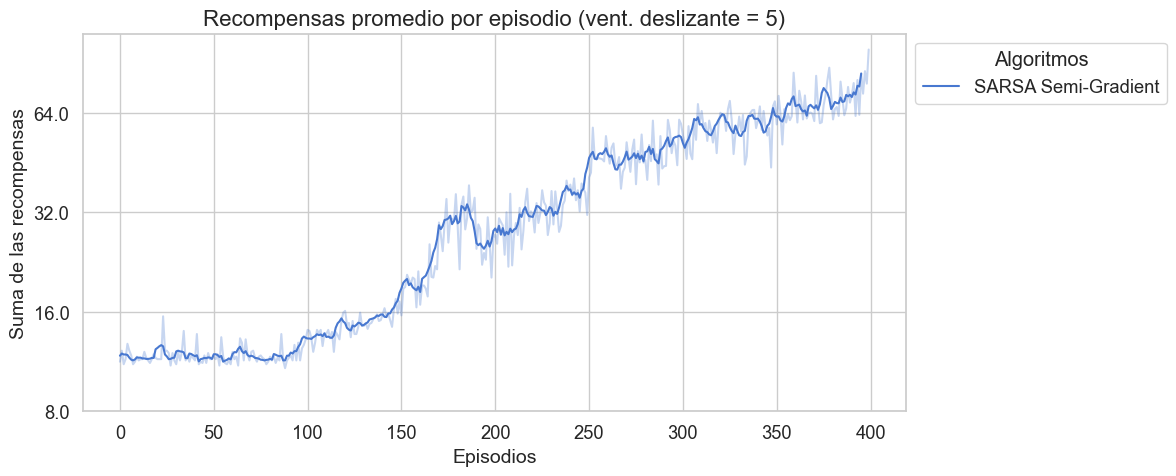

In [16]:
plotting.plot_rewards([rewards_sarsasemigradient],
                      ["SARSA Semi-Gradient"],
                      log_scale=True,
                      rolling_window=5)

Podemos observar que durante prácticamente los primeros 150 episodios hay un estancamiento geeneralizado del agoritmo, sin señales de aprendizaje. A partir del episodio 150, de forma lineal, el algoritmo consigue aprender sustancialmente hasta llegar a relativos niveles de covergencia en torno a los 350 episodios. Esta gráfica nos transmite la sensación de que quizás este algoritmo se beneficie de una ampliación de la cantidad de episodios de aprendizaje.

A continuación se muestra la longitud promedio de cada episodio:

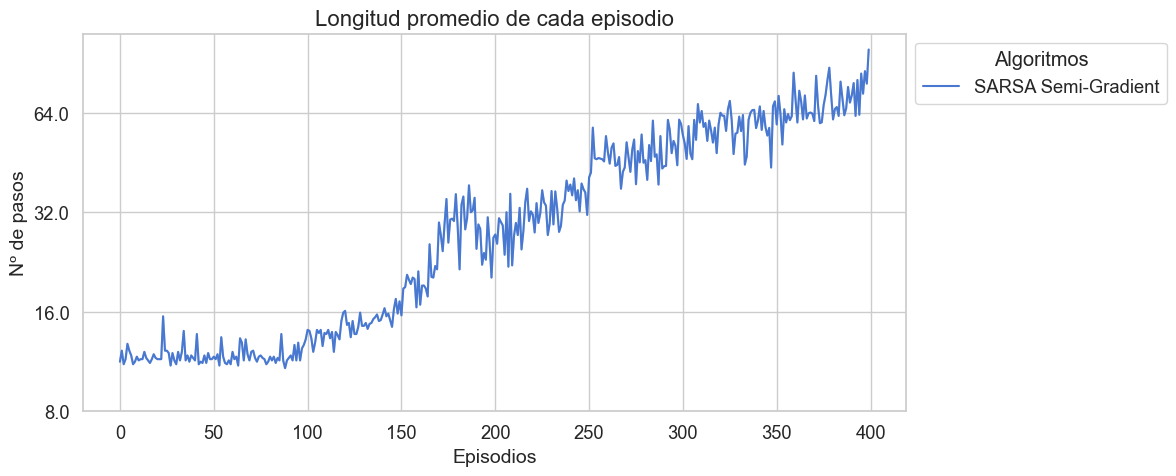

In [18]:
plotting.plot_episode_lengths([episode_lengths_sarsasemigradient],
                                ["SARSA Semi-Gradient"],
                                log_scale=True,
                                rolling_window=1)

Podemos ver que no se llegan a completar esos 400 pasos en ningún momento a lo largo de todos los espisodios, es decir, el carro llega de forma relativamente temprana al border de la imagen. En los primeros 150 episodios la cantidad de pasos se sitúa en torno a los 16 pasos. Al final de los episodios se consigue exceder los 128 pasos, sin embargo, este número representa menos de la mitad del límite de pasos establecido (400).

Por último, mostramos el error de entrenamiento promedio por episodio:

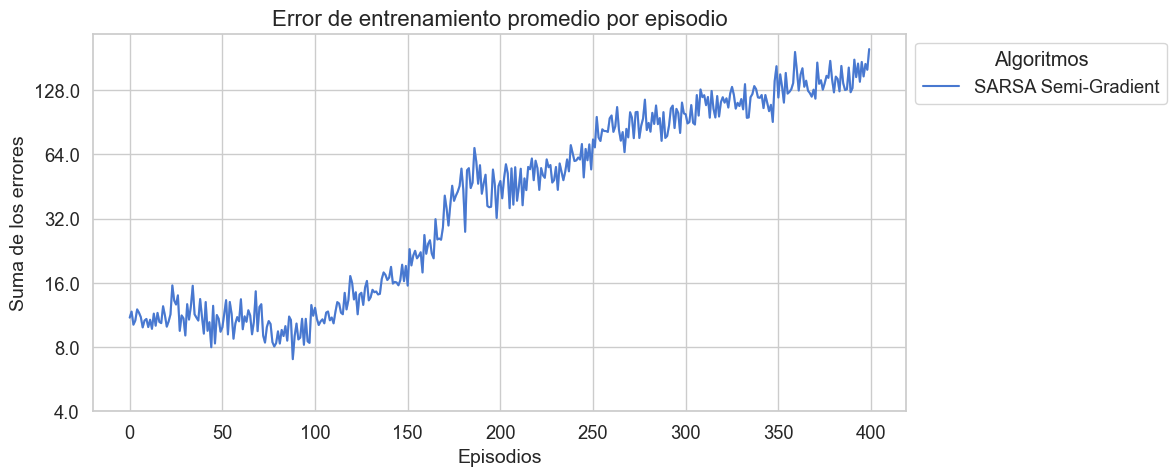

In [19]:
plotting.plot_training_errors([stats_sarsasemigradient['cum_training_error']],
                                ["SARSA Semi-Gradient"],
                                log_scale=True,
                                rolling_window=1)

Podemos observar que la suma de los errores avanza conforme se avanza en los episodios, llegando hasta el error sumado de 128, algo que tiene sentido, dado que cuanto más dure el episodio más errores se cometen cuantitativamente, pero menos proporcionalmente respecto a cuanto dura cada episodio.

Ahora, guardemos en formato GIF el modelo entrenado con una nueva instancia de CartPole:

In [20]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
base_env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n=4)
frames = run_episode_greedy(base_env, learner_sarsasemigradient, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_sarsasemigradient.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_sarsasemigradient.gif


### Algoritmos Deep Q

Ahora, vamos a analizar en conjunto ambos algoritmos Deep Q Learning propuestos, comencemos con las recompensas promedio por episodio:

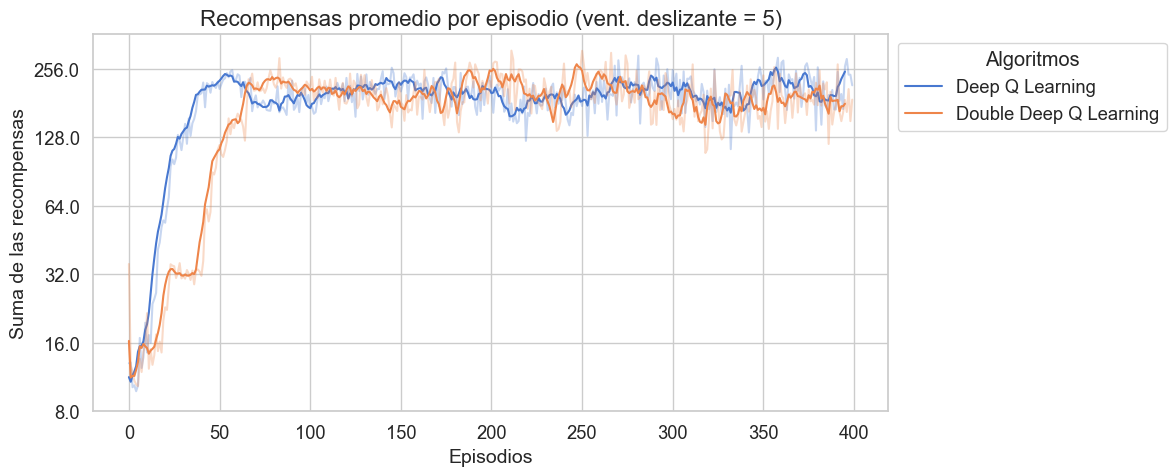

In [21]:
plotting.plot_rewards([rewards_deepqlearning, rewards_doubledeepqlearning],
                      ["Deep Q Learning", "Double Deep Q Learning"],
                      log_scale=True,
                      rolling_window=5)

Podemos observar que el algoritmo de Deep Q Learning consigue una mejor estabilización respecto a Double Deep Q Learning con una convergencia más temprana que el segundo algoritmo. Algo que coincide con el análisis de los métodos tabulares. En algunos insantes Double Deep Q Learning supera a Deep Q Learning, sin embargo, el primero es más estable.

Vamos a observar las recompensas de los últimos 50 episodios para cada uno de los algoritmos entrenados:

In [17]:
print("Media de las recompensas de los últimos 50 episodios:")
print("sarsa semigradient:", rewards_sarsasemigradient[-50:].mean())
print("deepqlearning:", rewards_deepqlearning[-50:].mean())
print("doubledeepqlearning:", rewards_doubledeepqlearning[-50:].mean())

Media de las recompensas de los últimos 50 episodios:
sarsa semigradient: 69.418
deepqlearning: 218.262
doubledeepqlearning: 189.056


Curiosamente, podemos ver que sarsa tiene las peores recompensas obtenidas y Double Deep Q y Deep Q Learning tienen reocmpensas bastante parecidas.

Ahora, observemos el comportamiento de la longitud promedia de cada episodio:

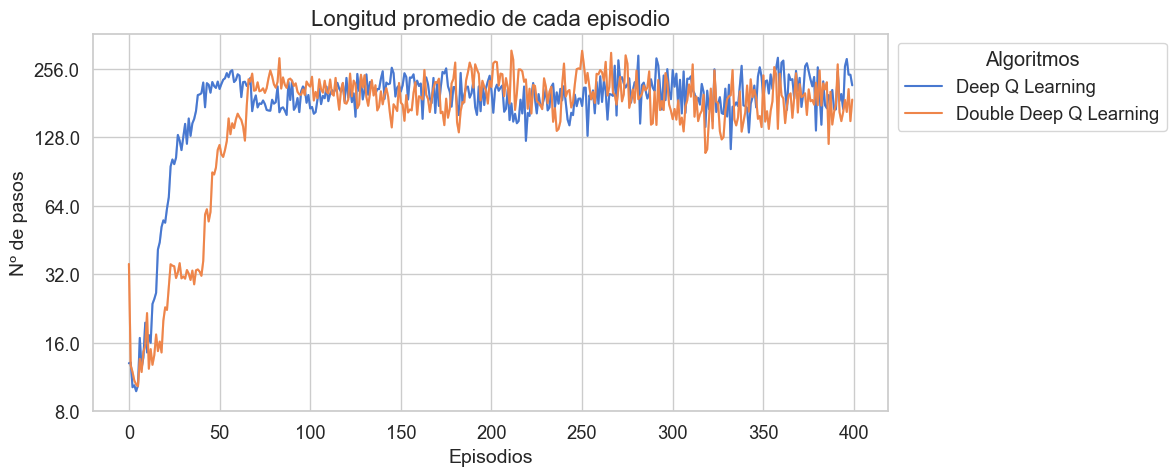

In [22]:
plotting.plot_episode_lengths([episode_lengths_deepqlearning, episode_lengths_doubledeepqlearning],
                                ["Deep Q Learning", "Double Deep Q Learning"],
                                log_scale=True,
                                rolling_window=1)

Podemos ver, que si bien se siguen repitiendo los patrones que los ya expuestos con las recompensas promedias por cada episodio, la cercania producida entre Deep Q Learning y Double Deep Q Learning, respecto a la longitud, es bastante parecida. Esto se debe también a consecuencia del ruido entre episodios, permitiendo un mayro solapamiento entre estos.

Por último, mostramos el error de entrenamiento promedio por episodio:

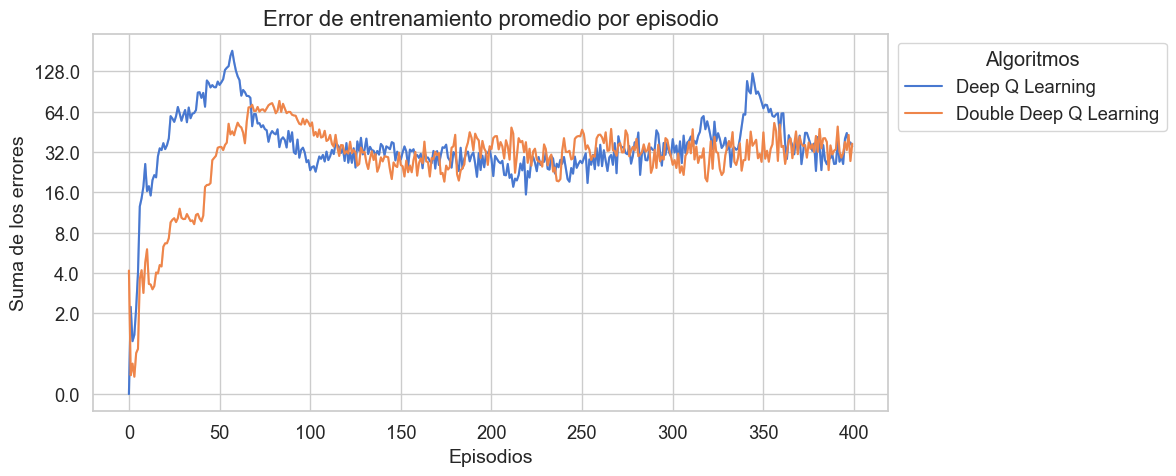

In [23]:
plotting.plot_training_errors([stats_deepqlearning['cum_training_error'], stats_doubledeepqlearning['cum_training_error']],
                                ["Deep Q Learning", "Double Deep Q Learning"],
                                log_scale=True,
                                rolling_window=1)

Podemos observar algo bastante curioso, y es que, Double Deep Q Learning tiene un erorr de entrenamiento promedio máximo inferior respecto a Deep Q Learning. Inicialmente el error de entrenamiento promedio para ambos modelos es bastante alto, sin embargo, alrededor del episodio 100 se produce un estancamiento del error de entrenamiento promedio, es decir, no se llega a reducir más, algo que concuerda con las recompensas promedio obtenidas con estos algoritmos. Para añadir, podemos observar que, curiosamente, en Deep Q Learning, observamos un **spyke** de error de entrenamiento promedio por episodio.

Finalmente, generemos los GIF de CartPole para ambos algoritmos DeepQ ya entrenados:

In [24]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames = run_episode_greedy(base_env, learner_deepqlearning, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_deepqlearning.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_deepqlearning.gif


In [25]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames = run_episode_greedy(base_env, learner_doubledeepqlearning, max_steps=1000)
base_env.close()
gif_path = frames_to_gif(frames, filename="cartpole_doubledeepqlearning.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_doubledeepqlearning.gif
